# Priors: `canna.lisa` vs arXiv:2204.04467

Strub et al. 2022 give their priors in Table V and the text of §III.B/§III.C. `canna.lisa` draws
its training prior in `LisaGB.sample_physical`, with the chirp mass coming from
`canna.lisa.priors.ChirpMass`. This notebook puts the two side by side, parameter by parameter, and
marks where the paper's own injected source falls in each.

The two are answering different questions, which is why they differ where they do. The paper's
prior is a **search** prior: deliberately wide and uninformative, defined *after* an optimiser has
already localised the source to a 1 µHz window, and narrowed again to a Fisher box before the
posterior is computed. canna's is a **training** prior: it has to be sampled from millions of
times to generate the data a flow learns on, so its support is the population of sources the
network should be able to handle, and its shape is the density the network will be calibrated to.

> **The amplitude prior has been changed since the first version of this notebook.** `LisaGB` used
> to draw the amplitude log-uniformly from a fixed box, `a_range = (1e-24, 1e-22)`. That box meant
> wildly different things at different frequencies — at 1.4 mHz it was $\rho \in [0.2, 17]$, so
> 76% of training draws fell below the $\rho = 7$ the paper treats as a detection floor. It is now
> `snr_range = (7, 1000)`, the paper's own range, converted to an amplitude at each window's centre
> frequency. Both are shown below.

Run with `.venv313/bin/python`, same kernel as `check_2204_04467.ipynb`.

In [1]:
import warnings
warnings.filterwarnings("ignore", message=r"Using `field\(init=False\)`")

import jax
jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp
import jax.random as jr
import numpy as np
import matplotlib.pyplot as plt

from canna.lisa import LisaGB
from canna.lisa.priors import ChirpMass, fdot_from_chirp_mass, chirp_mass_from_fdot
from canna.lisa.constants import SUN_MASS_TIME

# the paper's source (Table VII)
F0, LFDOT, AMP = 1.40457e-3, -17.3, 4.55e-23
LAM, BETA, IOTA, PSI, PHI0 = 1.5, 0.2, 1.2, 2.0, 3.0
T_OBS = 2 * 365.25 * 24 * 3600.0
FDOT = 10.0 ** LFDOT

N = 200_000

/home/giorgio/Desktop/ML/CANNA/.venv313/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/giorgio/Desktop/ML/CANNA/.venv313/lib/python3.13/site-packages/lisaconstants/compat/astropy.py:252: UserWarning: The following constants differ between lisaconstants and the version of astropy you have installed: VACUUM_PERMEABILITY. The recommended version of astropy is 7.2.0. Use a different one at your own risks. 
You may also open an issue at https://gitlab.esa.int/lisa-sgs/commons/lisa-constants to warn that lisaconstants is not compatible with astropy v8.0.1
  warnings.warn(


## canna's prior, as the code actually draws it

`LisaGB.sample_physical` needs a window centre, because `f0` is drawn log-uniformly over the part
of that window where a whole response fits. Everything else is window-independent. We use the
config-B problem, with a window sitting on the paper's source.

In [2]:
problem = LisaGB(n_sources=1, t_obs=T_OBS, f0_range=(1.0e-4, 12.0e-3))   # config B defaults
F_WINDOW = jnp.asarray(F0)

draws = jax.vmap(problem.sample_physical, in_axes=(0, None))(
    jr.split(jr.key(0), N), F_WINDOW)[:, 0, :]        # (N, 8), one source each

f0_c, mc_c, amp_c, lon_c, lat_c, psi_c, iota_lat_c, phi0_c = (np.asarray(draws[:, i]) for i in range(8))
fdot_c = np.asarray(fdot_from_chirp_mass(draws[:, 1], draws[:, 0]))
cos_iota_c = np.sin(iota_lat_c)          # column 6 is a latitude; iota = pi/2 - lat

print(f"f0 window for this centre : [{float(problem.f0_window(F_WINDOW)[0]) * 1e3:.6f}, "
      f"{float(problem.f0_window(F_WINDOW)[1]) * 1e3:.6f}] mHz  "
      f"({problem.window_bins} bins = {problem.window_bins / T_OBS * 1e6:.1f} uHz)")
print(f"global f0_range           : {problem.f0_range}")
print(f"snr_range                 : {problem.snr_range}")
print(f"  -> amplitude here       : [{float(problem.a_window(F_WINDOW)[0]):.3e}, "
      f"{float(problem.a_window(F_WINDOW)[1]):.3e}]")
print(f"chirp mass support        : ({problem.chirp_mass_range[0]:.3f}, "
      f"{problem.chirp_mass_range[1]:.3f}) Msun")

OLD_A_RANGE = (1e-24, 1e-22)          # what a_range used to be, for the before/after panels

f0 window for this centre : [1.380080, 1.428753] mHz  (4096 bins = 64.9 uHz)
global f0_range           : (0.0001, 0.012)
snr_range                 : (7.0, 1000.0)
  -> amplitude here       : [3.123e-23, 4.462e-21]
chirp mass support        : (0.131, 1.219) Msun


## The paper's prior

Table V, verbatim:

| parameter | lower | upper |
|---|---|---|
| $\sin\beta$ | $-1$ | $1$ |
| $\lambda$ | $-\pi$ | $\pi$ |
| $\dot f$ | $1.26\times10^{-10} f^{11/3}$ | $1.02\times10^{-6} f^{11/3}$ |
| $\cos\iota$ | $-1$ | $1$ |
| $\phi_0$ | $0$ | $2\pi$ |
| $\psi$ | $0$ | $\pi$ |

plus $f$ uniform over the 1 µHz search window, and no prior on $\mathcal{A}$ — it is maximised
analytically. Their *search box* for the amplitude does have edges, set by $\rho \in [7, 1000]$
through their Eq. (17), $\mathcal{A}(\rho) = 2\rho\,[\,T_{\rm obs}\sin^2(f/f_*)/S(f)\,]^{-1/2}$.

The $\dot f$ bounds are quoted as coming from $\dot f = \frac{96}{5}\pi^{8/3}\mathcal{M}^{5/3}f^{11/3}$
with $m_1 = m_2 = 1.4\,M_\odot$ above and $\mathcal{M} = 0.1\,M_\odot$ below. Those do not quite
reproduce the printed coefficients, so we invert the coefficients instead and use whatever chirp
masses they actually imply.

In [3]:
PAPER_FDOT_LO_COEFF, PAPER_FDOT_HI_COEFF = 1.26e-10, 1.02e-6


def fdot_coeff(chirp_mass):
    """dfdot/df^(11/3): the paper's radiation-reaction law, chirp mass in Msun."""
    return 96.0 / 5.0 * np.pi ** (8 / 3) * (SUN_MASS_TIME * chirp_mass) ** (5 / 3)


def coeff_to_chirp_mass(coeff):
    return (coeff / (96.0 / 5.0 * np.pi ** (8 / 3))) ** 0.6 / SUN_MASS_TIME


print(f"{'':34s}{'coefficient':>14s}{'implied Mc [Msun]':>20s}")
print(f"{'paper, lower bound':34s}{PAPER_FDOT_LO_COEFF:14.3g}"
      f"{coeff_to_chirp_mass(PAPER_FDOT_LO_COEFF):20.4f}")
print(f"{'paper, upper bound':34s}{PAPER_FDOT_HI_COEFF:14.3g}"
      f"{coeff_to_chirp_mass(PAPER_FDOT_HI_COEFF):20.4f}")
print(f"{'text: Mc = 0.1 (lower)':34s}{fdot_coeff(0.1):14.3g}{0.1:20.4f}")
print(f"{'text: m1 = m2 = 1.4 (upper)':34s}{fdot_coeff(1.4 * 2**-0.2):14.3g}"
      f"{1.4 * 2**-0.2:20.4f}")
print(f"\nUpper bound: the printed coefficient is {PAPER_FDOT_HI_COEFF / fdot_coeff(1.4 * 2**-0.2):.2f}x "
      f"the m1 = m2 = 1.4 value, and implies Mc = {coeff_to_chirp_mass(PAPER_FDOT_HI_COEFF):.3f}.")
print( "             So they put Mc = 1.4 straight into the formula rather than the chirp mass of")
print( "             a 1.4 + 1.4 pair (which is 1.4 / 2^0.2 = 1.219). The table is self-consistent.")
print(f"\nLower bound: the printed coefficient is {fdot_coeff(0.1) / PAPER_FDOT_LO_COEFF:.0f}x *below* "
      f"the Mc = 0.1 value the text quotes,")
print(f"             implying Mc = {coeff_to_chirp_mass(PAPER_FDOT_LO_COEFF):.4f} instead. Two digits look")
print( "             to have shifted. It makes no difference to their result -- they narrow to")
print( "             log fdot in [-18.5, -16] before sampling anyway. We use the printed values.")

MC_PAPER_LO = coeff_to_chirp_mass(PAPER_FDOT_LO_COEFF)
MC_PAPER_HI = coeff_to_chirp_mass(PAPER_FDOT_HI_COEFF)

# the paper's prior is log-uniform in fdot at fixed f, hence log-uniform in Mc too
rng = np.random.default_rng(0)
lfdot_p = rng.uniform(np.log10(PAPER_FDOT_LO_COEFF * F0 ** (11 / 3)),
                      np.log10(PAPER_FDOT_HI_COEFF * F0 ** (11 / 3)), N)
mc_p = chirp_mass_from_fdot(10.0**lfdot_p, F0)

                                     coefficient   implied Mc [Msun]
paper, lower bound                      1.26e-10              0.0063
paper, upper bound                      1.02e-06              1.4034
text: Mc = 0.1 (lower)                  1.25e-08              0.1000
text: m1 = m2 = 1.4 (upper)             8.06e-07              1.2188

Upper bound: the printed coefficient is 1.27x the m1 = m2 = 1.4 value, and implies Mc = 1.403.
             So they put Mc = 1.4 straight into the formula rather than the chirp mass of
             a 1.4 + 1.4 pair (which is 1.4 / 2^0.2 = 1.219). The table is self-consistent.

Lower bound: the printed coefficient is 99x *below* the Mc = 0.1 value the text quotes,
             implying Mc = 0.0063 instead. Two digits look
             to have shifted. It makes no difference to their result -- they narrow to
             log fdot in [-18.5, -16] before sampling anyway. We use the printed values.


## Amplitude: what their $\rho \in [7, 1000]$ box means here

Their Eq. (17) is $\mathcal{A}(\rho) = 2\rho\,[\,T_{\rm obs}\sin^2(f/f_*)/S(f)\,]^{-1/2}$, written
for a strain-convention $S$. Feeding canna's `noise_psd` into it directly does not work — the two
are in different units, and the mismatch is a factor running linearly in $f$ (it is $1$ at 2 mHz,
$0.1$ at 0.2 mHz, $3$ at 6 mHz), which is exactly the fractional-length/fractional-frequency trap.

So `LisaGB.a_window` carries the same *idea* in canna's own units: the frequency dependence comes
from `sky_averaged_sensitivity` (Robson, Cornish & Liu 2019), and the leftover $O(1)$ is measured
against `LisaGB.snr` itself rather than taken from a paper. `tests/lisa/test_amplitude_prior.py`
re-derives it by Monte Carlo, so it cannot drift.

In [4]:
from canna.lisa.priors import chirp_mass_from_fdot as _cmf

theta_ref = jnp.array([[F0, float(_cmf(FDOT, F0)), AMP,
                        1.486238, 0.607903,           # the equatorial sky of the paper's source
                        PSI, jnp.pi / 2 - IOTA, PHI0]])
rho_at_amp = float(problem.snr(theta_ref, F_WINDOW))
A_OF_RHO = AMP / rho_at_amp     # at THIS source's angles, for placing it on the plots

PAPER_A_LO, PAPER_A_HI = (float(v) for v in problem.a_window(F_WINDOW))
print(f"the paper's source: rho = {rho_at_amp:.3f} at A = {AMP:.3e}")
print(f"\nnew amplitude window at {F0 * 1e3:.3f} mHz, snr_range {problem.snr_range}:")
print(f"  [{PAPER_A_LO:.3e}, {PAPER_A_HI:.3e}]")
print(f"old fixed a_range:")
print(f"  [{OLD_A_RANGE[0]:.3e}, {OLD_A_RANGE[1]:.3e}]"
      f"   = rho in [{OLD_A_RANGE[0] / A_OF_RHO:.1f}, {OLD_A_RANGE[1] / A_OF_RHO:.0f}] "
      f"at this source's angles")

print(f"\nhow the new window moves across the band (faint edge, rho = {problem.snr_range[0]:.0f}):")
for f0 in (1e-4, 3e-4, 1e-3, 3e-3, 6e-3, 1.2e-2):
    lo, _ = problem.a_window(jnp.asarray(f0))
    print(f"  {f0 * 1e3:6.2f} mHz   A = {float(lo):.3e}")

the paper's source: rho = 7.951 at A = 4.550e-23

new amplitude window at 1.405 mHz, snr_range (7.0, 1000.0):
  [3.123e-23, 4.462e-21]
old fixed a_range:
  [1.000e-24, 1.000e-22]   = rho in [0.2, 17] at this source's angles

how the new window moves across the band (faint edge, rho = 7):
    0.10 mHz   A = 2.256e-20
    0.30 mHz   A = 1.036e-21
    1.00 mHz   A = 6.276e-23
    3.00 mHz   A = 8.583e-24
    6.00 mHz   A = 5.847e-24
   12.00 mHz   A = 6.070e-24


## The comparison

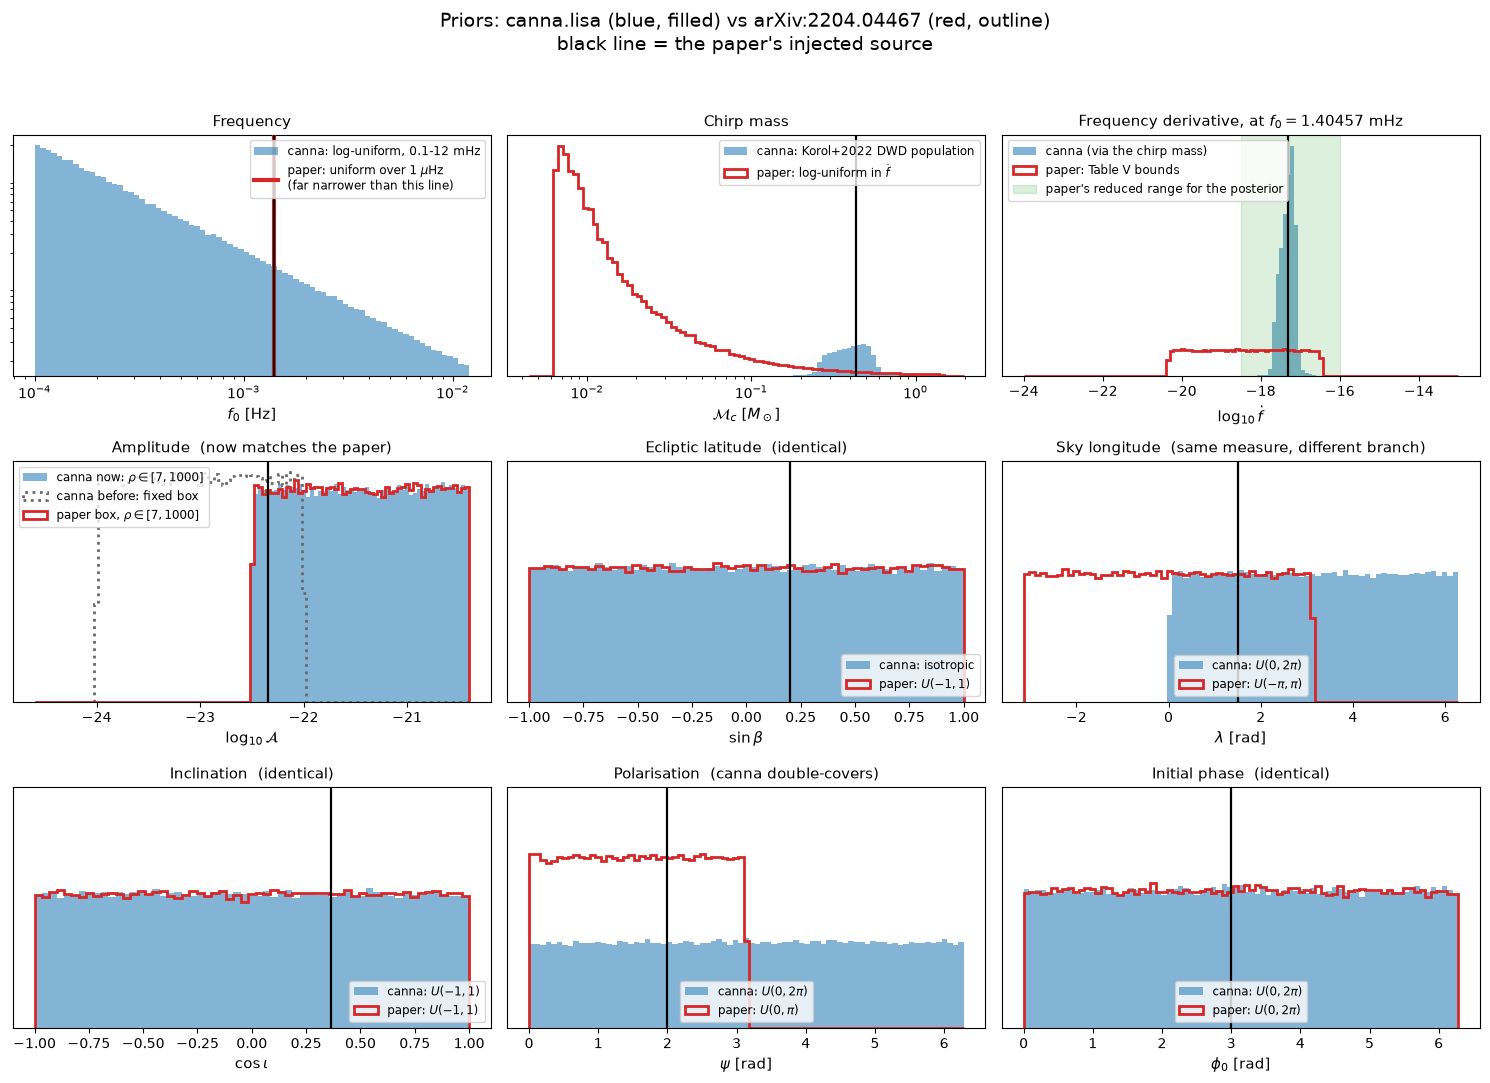

In [5]:
INJ = dict(f0=F0, mc=float(_cmf(FDOT, F0)), lfdot=LFDOT, lA=np.log10(AMP),
           sinb=np.sin(BETA), lam=LAM, cosi=np.cos(IOTA), psi=PSI, phi0=PHI0)

CANNA, PAPER = "tab:blue", "tab:red"
fig, axes = plt.subplots(3, 3, figsize=(15, 11))


def panel(ax, title, xlabel, injected=None, logx=False):
    ax.set_title(title, fontsize=11)
    ax.set_xlabel(xlabel, fontsize=11)
    ax.set_yticks([])
    if injected is not None:
        ax.axvline(injected, color="k", lw=1.6, ls="-", zorder=5)
    if logx:
        ax.set_xscale("log")


# --- f0 -------------------------------------------------------------------------------
ax = axes[0, 0]
edges = np.logspace(np.log10(problem.f0_range[0]), np.log10(problem.f0_range[1]), 80)
ax.hist(np.exp(rng.uniform(*np.log(problem.f0_range), N)), bins=edges, density=True,
        color=CANNA, alpha=0.55, label="canna: log-uniform, 0.1-12 mHz")
ax.axvline(F0, color=PAPER, lw=3, zorder=4,
           label=r"paper: uniform over 1 $\mu$Hz" "\n(far narrower than this line)")
ax.set_yscale("log")
panel(ax, "Frequency", "$f_0$ [Hz]", F0, logx=True)
ax.legend(fontsize=8.5, loc="upper right")

# --- chirp mass -----------------------------------------------------------------------
ax = axes[0, 1]
edges = np.logspace(np.log10(MC_PAPER_LO * 0.7), np.log10(MC_PAPER_HI * 1.4), 90)
ax.hist(mc_c, bins=edges, density=True, color=CANNA, alpha=0.55,
        label="canna: Korol+2022 DWD population")
ax.hist(mc_p, bins=edges, density=True, histtype="step", lw=2, color=PAPER,
        label=r"paper: log-uniform in $\dot f$")
ax.set_xscale("log")
panel(ax, "Chirp mass", r"$\mathcal{M}_c$ [$M_\odot$]", INJ["mc"])
ax.legend(fontsize=8.5)

# --- log fdot -------------------------------------------------------------------------
ax = axes[0, 2]
bins = np.linspace(-24, -13, 120)
ax.hist(np.log10(fdot_c), bins=bins, density=True, color=CANNA, alpha=0.55,
        label="canna (via the chirp mass)")
ax.hist(lfdot_p, bins=bins, density=True, histtype="step", lw=2, color=PAPER,
        label="paper: Table V bounds")
ax.axvspan(-18.5, -16.0, color="tab:green", alpha=0.16,
           label=r"paper's reduced range for the posterior")
panel(ax, r"Frequency derivative, at $f_0 = 1.40457$ mHz", r"$\log_{10}\dot f$", LFDOT)
ax.legend(fontsize=8.5, loc="upper left")

# --- log amplitude --------------------------------------------------------------------
ax = axes[1, 0]
bins = np.linspace(-24.6, -20.4, 110)
ax.hist(np.log10(amp_c), bins=bins, density=True, color=CANNA, alpha=0.55,
        label=r"canna now: $\rho\in[7,1000]$")
ax.hist(rng.uniform(*np.log10(OLD_A_RANGE), N), bins=bins, density=True,
        histtype="step", lw=2, ls=":", color="dimgray", label=r"canna before: fixed box")
ax.hist(rng.uniform(np.log10(PAPER_A_LO), np.log10(PAPER_A_HI), N), bins=bins, density=True,
        histtype="step", lw=2, color=PAPER, label=r"paper box, $\rho\in[7,1000]$")
panel(ax, "Amplitude  (now matches the paper)", r"$\log_{10}\mathcal{A}$", INJ["lA"])
ax.legend(fontsize=8.5, loc="upper left")

# --- sin beta -------------------------------------------------------------------------
ax = axes[1, 1]
bins = np.linspace(-1, 1, 60)
ax.hist(np.sin(lat_c), bins=bins, density=True, color=CANNA, alpha=0.55, label="canna: isotropic")
ax.hist(rng.uniform(-1, 1, N), bins=bins, density=True, histtype="step", lw=2, color=PAPER,
        label="paper: $U(-1,1)$")
ax.set_ylim(0, 0.9)
panel(ax, "Ecliptic latitude  (identical)", r"$\sin\beta$", INJ["sinb"])
ax.legend(fontsize=8.5, loc="lower right")

# --- longitude ------------------------------------------------------------------------
ax = axes[1, 2]
bins = np.linspace(-np.pi, 2 * np.pi, 80)
ax.hist(lon_c, bins=bins, density=True, color=CANNA, alpha=0.55, label=r"canna: $U(0,2\pi)$")
ax.hist(rng.uniform(-np.pi, np.pi, N), bins=bins, density=True, histtype="step", lw=2,
        color=PAPER, label=r"paper: $U(-\pi,\pi)$")
ax.set_ylim(0, 0.3)
panel(ax, "Sky longitude  (same measure, different branch)", r"$\lambda$ [rad]", INJ["lam"])
ax.legend(fontsize=8.5, loc="lower center")

# --- cos iota -------------------------------------------------------------------------
ax = axes[2, 0]
bins = np.linspace(-1, 1, 60)
ax.hist(cos_iota_c, bins=bins, density=True, color=CANNA, alpha=0.55, label="canna: $U(-1,1)$")
ax.hist(rng.uniform(-1, 1, N), bins=bins, density=True, histtype="step", lw=2, color=PAPER,
        label="paper: $U(-1,1)$")
ax.set_ylim(0, 0.9)
panel(ax, "Inclination  (identical)", r"$\cos\iota$", INJ["cosi"])
ax.legend(fontsize=8.5, loc="lower right")

# --- psi ------------------------------------------------------------------------------
ax = axes[2, 1]
bins = np.linspace(0, 2 * np.pi, 80)
ax.hist(psi_c, bins=bins, density=True, color=CANNA, alpha=0.55, label=r"canna: $U(0,2\pi)$")
ax.hist(rng.uniform(0, np.pi, N), bins=bins, density=True, histtype="step", lw=2, color=PAPER,
        label=r"paper: $U(0,\pi)$")
ax.set_ylim(0, 0.45)
panel(ax, r"Polarisation  (canna double-covers)", r"$\psi$ [rad]", INJ["psi"])
ax.legend(fontsize=8.5, loc="lower center")

# --- phi0 -----------------------------------------------------------------------------
ax = axes[2, 2]
bins = np.linspace(0, 2 * np.pi, 80)
ax.hist(phi0_c, bins=bins, density=True, color=CANNA, alpha=0.55, label=r"canna: $U(0,2\pi)$")
ax.hist(rng.uniform(0, 2 * np.pi, N), bins=bins, density=True, histtype="step", lw=2, color=PAPER,
        label=r"paper: $U(0,2\pi)$")
ax.set_ylim(0, 0.28)
panel(ax, "Initial phase  (identical)", r"$\phi_0$ [rad]", INJ["phi0"])
ax.legend(fontsize=8.5, loc="lower center")

fig.suptitle("Priors: canna.lisa (blue, filled) vs arXiv:2204.04467 (red, outline)\n"
             "black line = the paper's injected source", fontsize=14)
fig.tight_layout(rect=(0, 0, 1, 0.955))
plt.show()

## What the two priors imply for the SNR

This is the test that matters: the priors agree if and only if they put the same sources at the
same loudness. The paper's box is defined *as* $\rho \in [7, 1000]$, so canna's draws should land
there too — and, unlike before, at **every** frequency rather than just one.

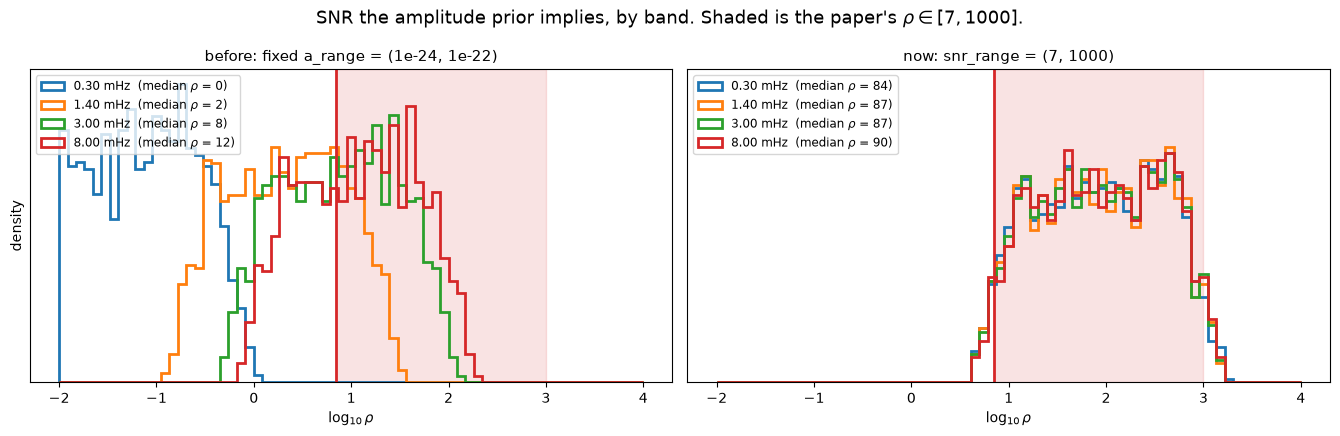

        band   median rho   % below 7   % in [7,1000]


     0.30 mHz           84         3.2            94.3


     1.40 mHz           87         3.3            94.0


     3.00 mHz           87         3.4            93.7


     8.00 mHz           90         2.8            94.0

the paper's source sits at rho = 7.95


In [6]:
def window_on(f0):
    """Centre of the window LisaGB would slide onto f0."""
    lo, hi = problem.window_index_range
    index = np.clip(round(f0 * T_OBS / problem.wdm_times - problem.wdm_freq_bands / 4), lo, hi)
    return jnp.asarray((index * problem.wdm_times + problem.window_bins / 2) / T_OBS)


def prior_snrs(f, n=1500, old_box=False):
    """SNR of n draws from the prior, in the window centred at f."""
    p = jax.vmap(problem.sample_physical, in_axes=(0, None))(jr.split(jr.key(1), n), f)
    if old_box:                       # re-draw the amplitude from the retired fixed box
        u = jr.uniform(jr.key(2), (n, 1, 1))
        p = p.at[..., 2:3].set(jnp.exp(u * np.log(OLD_A_RANGE[1] / OLD_A_RANGE[0])
                                       + np.log(OLD_A_RANGE[0])))
    return np.asarray(jax.lax.map(lambda q: problem.snr(q, f), p))


BANDS = [3.0e-4, 1.40457e-3, 3.0e-3, 8.0e-3]
fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.4), sharey=True, sharex=True)
bins = np.linspace(-2.0, 4.0, 70)          # histogram log10(rho): density on a log axis lies
for ax, use_old, title in zip(axes, (True, False),
                              ("before: fixed a_range = (1e-24, 1e-22)",
                               "now: snr_range = (7, 1000)")):
    for f0 in BANDS:
        s_ = prior_snrs(window_on(f0), old_box=use_old)
        ax.hist(np.log10(s_), bins=bins, density=True, histtype="step", lw=2,
                label=f"{f0 * 1e3:.2f} mHz  (median $\\rho$ = {np.median(s_):.0f})")
    ax.axvspan(np.log10(7), np.log10(1000), color=PAPER, alpha=0.13)
    ax.axvline(np.log10(7), color=PAPER, lw=2)
    ax.set_xlabel(r"$\log_{10}\rho$"); ax.set_yticks([])
    ax.set_title(title, fontsize=11); ax.legend(fontsize=8.5, loc="upper left")
axes[0].set_ylabel("density")
fig.suptitle(r"SNR the amplitude prior implies, by band. Shaded is the paper's $\rho\in[7,1000]$.",
             fontsize=13)
fig.tight_layout(); plt.show()

print(f"{'band':>12}{'median rho':>13}{'% below 7':>12}{'% in [7,1000]':>16}")
for f0 in BANDS:
    s_ = prior_snrs(window_on(f0))
    print(f"{f0 * 1e3:9.2f} mHz{np.median(s_):13.0f}{np.mean(s_ < 7) * 100:12.1f}"
          f"{np.mean((s_ >= 7) & (s_ <= 1000)) * 100:16.1f}")
print(f"\nthe paper's source sits at rho = {rho_at_amp:.2f}")

## Summary

| parameter | arXiv:2204.04467 | `canna.lisa` | same? |
|---|---|---|---|
| $f_0$ | uniform over a 1 µHz window | log-uniform over 0.1–12 mHz | different by construction |
| $\dot f$ / $\mathcal{M}_c$ | log-uniform in $\dot f$; $\mathcal{M}_c \in [0.006, 1.40]\,M_\odot$ | Korol+2022 DWD population, peaked near 0.45, support $[0.13, 1.22]$ | **very different, deliberately** |
| $\mathcal{A}$ | search box $\rho\in[7,1000]$ | `snr_range = (7, 1000)` | **now matched** |
| $\sin\beta$ | $U(-1,1)$ | $U(-1,1)$ | identical |
| $\lambda$ | $U(-\pi,\pi)$ | $U(0,2\pi)$ | identical measure |
| $\cos\iota$ | $U(-1,1)$ | $U(-1,1)$ | identical |
| $\psi$ | $U(0,\pi)$ | $U(0,2\pi)$ | canna double-covers |
| $\phi_0$ | $U(0,2\pi)$ | $U(0,2\pi)$ | identical |

**Amplitude — changed, and this is the substantive one.** `a_range = (1e-24, 1e-22)` is gone,
replaced by `snr_range = (7, 1000)`. The old fixed box meant something different at every
frequency: at 1.4 mHz it was $\rho \in [0.2, 17]$, with a median draw at $\rho = 2$ and 76% of
training sources below the paper's $\rho = 7$ detection floor, while at 0.3 mHz the same box was
fainter still. The new one asks for a matched-filter SNR and converts to an amplitude at each
window's centre frequency through `LisaGB.sky_averaged_sensitivity`, so the training set is the
same population of *detectable* sources everywhere in the band — which is what the flow needs to
be calibrated on, and what the paper was asking for all along.

Worth knowing about the conversion: the paper's Eq. (17) cannot be used with canna's `noise_psd`
as written, because their $S$ is a strain-convention PSD and ours is fractional-frequency. The
mismatch is a factor linear in $f$ — unity at 2 mHz, $0.1$ at 0.2 mHz, $3$ at 6 mHz — so it would
have tilted the prior across the band rather than just rescaling it. `a_window` therefore takes the
*shape* from Robson–Cornish–Liu and measures the remaining $O(1)$ against `LisaGB.snr` directly.
That constant is flat to 0.1% below 1.5 mHz and drifts ~7% by 12 mHz, which is RCL's own
$1 + 0.6(f/f_*)^2$ approximation running out, not the response.

**The four angles agree.** Sky, inclination and initial phase are drawn identically, and
$\lambda$'s branch cut is cosmetic. Nothing to do there.

**$\psi$ is the remaining cheap fix.** A gravitational wave is invariant under $\psi \to \psi+\pi$,
so the paper's $U(0,\pi)$ covers the physical range exactly once while canna's $U(0,2\pi)$ covers
it twice. Harmless for a likelihood, but for a flow it makes the target density exactly bimodal in
$\psi$ — every source has a twin half a turn away — so the network spends capacity learning a
symmetry rather than physics. Not a one-line edit, though: `physical_to_flow` lifts $(\psi, \iota)$
onto a `geometries.Spherical(3)` together, and the full degeneracy is
$(\psi, \phi_0) \to (\psi+\pi, \phi_0)$ *and* $(\psi + \pi/2, \phi_0 + \pi)$, so halving the range
alone would not remove it.

**The chirp mass difference is deliberate and canna's choice is the right one.** The paper needs a
search prior wide enough to exclude nothing, so log-uniform in $\dot f$ over four decades is
sensible for them; it puts most of its mass at chirp masses no double white dwarf has, and over
most of that range $\dot f$ is unmeasurable anyway ($\dot f T_{\rm obs}^2 \ll 1$). canna draws the
astrophysical population instead. Their injected source, $\mathcal{M}_c = 0.434\,M_\odot$, sits
essentially **at the mode of canna's prior** — the $\log_{10}\dot f$ panel shows canna's spike
landing on the injected $-17.3$ — and around the 78th percentile of theirs.

Two bookkeeping notes on their Table V, neither of which affects their result (they narrow to
$\log\dot f \in [-18.5,-16]$ before sampling): the upper $\dot f$ bound corresponds to
$\mathcal{M}_c = 1.4$, i.e. they used 1.4 as the chirp mass rather than as the component masses of
a Chandrasekhar pair ($\mathcal{M}_c = 1.219$); and the printed lower bound is 99× below the
$\mathcal{M}_c = 0.1$ the text quotes.

**Still open.** $f_0$ remains log-uniform over the whole band, which is a training choice rather
than a population one — the astrophysical distribution falls steeply with frequency (Maoz et al.
2018), so a population-faithful $f_0$ prior would starve the high-frequency end of training data.
And the amplitude is still drawn independently of the chirp mass and distance; drawing it from
$\mathcal{A} = 2(G\mathcal{M}_c)^{5/3}(\pi f)^{2/3}/(c^4 d)$ with a Galactic distance model would
make the whole prior internally consistent, at the cost of no longer spanning a controlled SNR
range.